<a href="https://colab.research.google.com/github/ashishpandey10205/ML-project/blob/main/Fraud_detection_dataset_projects_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fraud detection using Machine learning
ALGORITHMS ---
1. LinearRegression
2. LogisticRegression
3. KNeighborsClassifier
4. DecisionTreeClassifier/Regression
5. RandomForestClassifier/Regression
6. EnsembleLearning

importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

loading / reading dataset

In [ ]:
df = pd.read_csv('/content/fraud_detection_dataset_v2.csv')
df

,transaction_id,customer_id,transaction_date,city,device_type,transaction_type,merchant_category,payment_method,account_age_days,transaction_amount,avg_transaction_amount,previous_transactions,failed_login_attempts,risk_score,is_fraud
0,2000000,25795,2024-10-30,Pune,Tablet,Online,Food,Net Banking,489,7557.35,2581.53,169,9,0.601,0
1,2000001,10860,2024-10-08,Bangalore,Desktop,ATM,Healthcare,Wallet,1223,3626.45,4462.66,513,8,0.648,0
2,2000002,86820,2024-07-09,Delhi,Desktop,POS,Healthcare,Wallet,655,4561.62,4418.63,333,1,0.183,0
3,2000003,64886,2024-10-18,Bangalore,Tablet,UPI,Utilities,Debit Card,1084,3852.07,2410.83,15,1,0.936,0
4,2000004,16265,2024-05-31,Pune,Tablet,UPI,Gaming,Credit Card,2456,5009.51,5031.36,382,1,0.905,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18245,2004152,68002,2024-11-05,Bangalore,Mobile,POS,Electronics,UPI,1716,10297.59,4891.38,323,0,0.956,0
18246,2001631,11435,2024-02-28,Kolkata,Mobile,ATM,Travel,Net Banking,1312,6331.98,5953.63,231,10,0.947,0
18247,2014551,41661,2024-12-03,Kolkata,Desktop,UPI,Groceries,Wallet,2256,4570.06,4638.20,49,3,0.771,0
18248,2007217,96704,2024-09-30,Bangalore,Tablet,POS,Electronics,Credit Card,1569,8089.28,1545.67,338,4,0.449,0


shape of data

In [ ]:
df.shape

(18250, 15)

size of dataset

In [ ]:
df.size

273750

columns name in dataset

In [ ]:
df.columns

Index(['transaction_id', 'customer_id', 'transaction_date', 'city',
       'device_type', 'transaction_type', 'merchant_category',
       'payment_method', 'account_age_days', 'transaction_amount',
       'avg_transaction_amount', 'previous_transactions',
       'failed_login_attempts', 'risk_score', 'is_fraud'],
      dtype='object')

dataset information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18250 entries, 0 to 18249
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          18250 non-null  int64  
 1   customer_id             18250 non-null  int64  
 2   transaction_date        18250 non-null  object 
 3   city                    18250 non-null  object 
 4   device_type             18250 non-null  object 
 5   transaction_type        18250 non-null  object 
 6   merchant_category       18250 non-null  object 
 7   payment_method          18250 non-null  object 
 8   account_age_days        18250 non-null  int64  
 9   transaction_amount      17341 non-null  float64
 10  avg_transaction_amount  17334 non-null  float64
 11  previous_transactions   18250 non-null  int64  
 12  failed_login_attempts   18250 non-null  int64  
 13  risk_score              17331 non-null  float64
 14  is_fraud                18250 non-null

top 5 records from dataset

In [ ]:
df.head()

,transaction_id,customer_id,transaction_date,city,device_type,transaction_type,merchant_category,payment_method,account_age_days,transaction_amount,avg_transaction_amount,previous_transactions,failed_login_attempts,risk_score,is_fraud
0,2000000,25795,2024-10-30,Pune,Tablet,Online,Food,Net Banking,489,7557.35,2581.53,169,9,0.601,0
1,2000001,10860,2024-10-08,Bangalore,Desktop,ATM,Healthcare,Wallet,1223,3626.45,4462.66,513,8,0.648,0
2,2000002,86820,2024-07-09,Delhi,Desktop,POS,Healthcare,Wallet,655,4561.62,4418.63,333,1,0.183,0
3,2000003,64886,2024-10-18,Bangalore,Tablet,UPI,Utilities,Debit Card,1084,3852.07,2410.83,15,1,0.936,0
4,2000004,16265,2024-05-31,Pune,Tablet,UPI,Gaming,Credit Card,2456,5009.51,5031.36,382,1,0.905,0


describtion of datset

In [ ]:
df.describe()

,transaction_id,customer_id,account_age_days,transaction_amount,avg_transaction_amount,previous_transactions,failed_login_attempts,risk_score,is_fraud
count,1.825000e+04,18250.000000,18250.000000,17341.000000,17334.000000,18250.000000,18250.000000,17331.000000,18250.000000
mean,2.009000e+06,54682.740055,1253.761534,5450.504105,3478.165108,297.589425,5.522137,0.501441,0.075781
std,5.193811e+03,26259.792200,713.965134,4140.186458,1504.155771,173.766037,3.471746,0.287811,0.264654
min,2.000000e+06,10002.000000,10.000000,-6988.000000,-2230.000000,0.000000,0.000000,0.000000,0.000000
25%,2.004508e+06,31779.500000,633.000000,3397.760000,2464.537500,146.000000,2.000000,0.256000,0.000000
50%,2.009002e+06,54468.000000,1263.000000,5080.820000,3477.770000,295.000000,6.000000,0.500000,0.000000
75%,2.013500e+06,77641.000000,1863.000000,6846.530000,4488.665000,448.000000,9.000000,0.748000,0.000000
max,2.017999e+06,99987.000000,2499.000000,68492.700000,9252.380000,599.000000,11.000000,1.000000,1.000000


value counts of dataset

In [ ]:
df.value_counts()

,,,,,,,,,,,,,,,count
transaction_id,customer_id,transaction_date,city,device_type,transaction_type,merchant_category,payment_method,account_age_days,transaction_amount,avg_transaction_amount,previous_transactions,failed_login_attempts,risk_score,is_fraud,
2002514,24291,2024-05-20,Mumbai,Desktop,Online,Utilities,Wallet,1373,4651.32,3856.21,262,3,0.332,0,2
2011108,50768,2024-05-06,Mumbai,Tablet,POS,Groceries,Wallet,1286,4859.60,2076.48,219,6,0.119,0,2
2005879,21350,2024-08-05,Pune,Tablet,POS,Travel,Credit Card,2125,3587.96,3061.66,67,0,0.379,0,2
2011974,44875,2024-03-31,Kolkata,Tablet,POS,Healthcare,Wallet,1802,5326.29,5094.42,358,2,0.732,0,2
2004029,48402,2024-10-09,Noida,Tablet,POS,Healthcare,Debit Card,487,7212.48,825.90,566,7,0.870,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006053,60383,2024-03-16,Pune,Desktop,ATM,Fashion,Debit Card,2334,6600.66,4387.18,9,4,0.674,0,1
2006054,19837,2024-01-30,Ahmedabad,Mobile,ATM,Fashion,Debit Card,581,3539.72,3951.26,280,7,0.997,0,1
2006056,46824,2024-05-05,Mumbai,Tablet,POS,Food,Wallet,86,5282.50,2424.88,120,3,0.671,0,1


 uniqueness in dataset

In [ ]:
df.nunique

<bound method DataFrame.nunique of        transaction_id  customer_id transaction_date       city device_type  \
0             2000000        25795       2024-10-30       Pune      Tablet   
1             2000001        10860       2024-10-08  Bangalore     Desktop   
2             2000002        86820       2024-07-09      Delhi     Desktop   
3             2000003        64886       2024-10-18  Bangalore      Tablet   
4             2000004        16265       2024-05-31       Pune      Tablet   
...               ...          ...              ...        ...         ...   
18245         2004152        68002       2024-11-05  Bangalore      Mobile   
18246         2001631        11435       2024-02-28    Kolkata      Mobile   
18247         2014551        41661       2024-12-03    Kolkata     Desktop   
18248         2007217        96704       2024-09-30  Bangalore      Tablet   
18249         2016207        69331       2024-10-18      Noida      Tablet   

      transaction_type merchant_category payment_method  account_age_days  \
0               Online              Food    Net Banking               489   
1                  ATM        Healthcare         Wallet              1223   
2                  POS        Healthcare         Wallet               655   
3                  UPI         Utilities     Debit Card              1084   
4                  UPI            Gaming    Credit Card              2456   
...                ...               ...            ...               ...   
18245              POS       Electronics            UPI              1716   
18246              ATM            Travel    Net Banking              1312   
18247              UPI         Groceries         Wallet              2256   
18248              POS       Electronics    Credit Card              1569   
18249              ATM           Fashion    Credit Card              2259   

       transaction_amount  avg_transaction_amount  previous_transactions  \
0                 7557.35                 2581.53                    169   
1                 3626.45                 4462.66                    513   
2                 4561.62                 4418.63                    333   
3                 3852.07                 2410.83                     15   
4                 5009.51                 5031.36                    382   
...                   ...                     ...                    ...   
18245            10297.59                 4891.38                    323   
18246             6331.98                 5953.63                    231   
18247             4570.06                 4638.20                     49   
18248             8089.28                 1545.67                    338   
18249             4661.94                 4314.97                    470   

       failed_login_attempts  risk_score  is_fraud  
0                          9       0.601         0  
1                          8       0.648         0  
2                          1       0.183         0  
3                          1       0.936         0  
4                          1       0.905         0  
...                      ...         ...       ...  
18245                      0       0.956         0  
18246                     10       0.947         0  
18247                      3       0.771         0  
18248                      4       0.449         0  
18249                      9       0.803         0  

[18250 rows x 15 columns]>

# Data cleaning ---

checking null values in datset

In [ ]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
transaction_date,0
city,0
device_type,0
transaction_type,0
merchant_category,0
payment_method,0
account_age_days,0
transaction_amount,909


null percenatge of each columns

In [ ]:
df.isnull().sum()/len(df)*100

,0
transaction_id,0.000000
customer_id,0.000000
transaction_date,0.000000
city,0.000000
device_type,0.000000
transaction_type,0.000000
merchant_category,0.000000
payment_method,0.000000
account_age_days,0.000000
transaction_amount,4.980822


filling null values
for categorical coln --- mode
for numerical column --- mean

In [ ]:
for i in df.columns:
  if df[i].dtypes == 'object':
    df[i] = df[i].fillna(df[i].mode()[0])
  else:
    df[i] = df[i].fillna(df[i].mean())

again checking whether null is filled or not

In [ ]:
df.isna().sum()

,0
transaction_id,0
customer_id,0
transaction_date,0
city,0
device_type,0
transaction_type,0
merchant_category,0
payment_method,0
account_age_days,0
transaction_amount,0


CHECKING DUPLICATES RECORDS IN DATASET

In [ ]:
df.duplicated().sum()

np.int64(250)

non duplicates record

In [ ]:
(~df.duplicated()).sum()

np.int64(18000)

only duplicates records

In [ ]:
df.loc[df.duplicated(),:]

,transaction_id,customer_id,transaction_date,city,device_type,transaction_type,merchant_category,payment_method,account_age_days,transaction_amount,avg_transaction_amount,previous_transactions,failed_login_attempts,risk_score,is_fraud
18000,2012076,58692,2024-02-21,Gurgaon,Mobile,Online,Utilities,Debit Card,465,5618.17,1885.93,353,6,0.164,0
18001,2001096,74644,2024-11-29,Delhi,Tablet,POS,Groceries,Wallet,472,5915.77,2573.48,422,2,0.671,0
18002,2010283,63836,2024-11-26,Delhi,Mobile,ATM,Electronics,Credit Card,960,4199.26,2286.80,382,8,0.353,0
18003,2008333,71892,2024-02-27,Chennai,Mobile,Online,Food,Debit Card,2348,3769.28,2277.79,317,9,0.263,0
18004,2003608,60961,2024-08-06,Bangalore,Tablet,UPI,Food,Credit Card,1912,7169.97,3103.25,374,6,0.077,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18245,2004152,68002,2024-11-05,Bangalore,Mobile,POS,Electronics,UPI,1716,10297.59,4891.38,323,0,0.956,0
18246,2001631,11435,2024-02-28,Kolkata,Mobile,ATM,Travel,Net Banking,1312,6331.98,5953.63,231,10,0.947,0
18247,2014551,41661,2024-12-03,Kolkata,Desktop,UPI,Groceries,Wallet,2256,4570.06,4638.20,49,3,0.771,0
18248,2007217,96704,2024-09-30,Bangalore,Tablet,POS,Electronics,Credit Card,1569,8089.28,1545.67,338,4,0.449,0


droping duplicates records from dataset

In [ ]:
df.drop_duplicates(inplace = True)

aagin checking whether duplicates removed or not

In [ ]:
df.duplicated().sum()

np.int64(0)

UNIQUENESS IN COLUMNS (Labeling)

In [ ]:
df['city'].unique()

array(['Pune', 'Bangalore', 'Delhi', 'Ahmedabad', 'Gurgaon', 'Noida',
       'Hyderabad', 'Mumbai', 'Chennai', 'Kolkata'], dtype=object)

In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,16626
1,1374


# DATA SEPARTION

FOR NUMERICAL COLN ONLY

In [ ]:
df_num = df.select_dtypes(include =np.number)
df_num

,transaction_id,customer_id,account_age_days,transaction_amount,avg_transaction_amount,previous_transactions,failed_login_attempts,risk_score,is_fraud
0,2000000,25795,489,7557.35,2581.53,169,9,0.601,0
1,2000001,10860,1223,3626.45,4462.66,513,8,0.648,0
2,2000002,86820,655,4561.62,4418.63,333,1,0.183,0
3,2000003,64886,1084,3852.07,2410.83,15,1,0.936,0
4,2000004,16265,2456,5009.51,5031.36,382,1,0.905,0
...,...,...,...,...,...,...,...,...,...
17995,2017995,19275,2126,4524.31,3039.84,577,2,0.395,0
17996,2017996,55606,2434,4694.37,3060.48,556,3,0.316,1
17997,2017997,11658,2221,7793.87,5599.38,214,2,0.077,0
17998,2017998,82468,564,9124.80,3432.53,328,2,0.120,0


FOR CATEGORICAL COLN ONLY

In [ ]:
df_cat = df.select_dtypes(include ='object')
df_cat

,transaction_date,city,device_type,transaction_type,merchant_category,payment_method
0,2024-10-30,Pune,Tablet,Online,Food,Net Banking
1,2024-10-08,Bangalore,Desktop,ATM,Healthcare,Wallet
2,2024-07-09,Delhi,Desktop,POS,Healthcare,Wallet
3,2024-10-18,Bangalore,Tablet,UPI,Utilities,Debit Card
4,2024-05-31,Pune,Tablet,UPI,Gaming,Credit Card
...,...,...,...,...,...,...
17995,2024-06-27,Chennai,Tablet,UPI,Utilities,Wallet
17996,2024-11-25,Gurgaon,Desktop,UPI,Fashion,Debit Card
17997,2024-04-10,Pune,Desktop,UPI,Food,Credit Card
17998,2024-06-24,Kolkata,Tablet,UPI,Healthcare,Wallet


OUTLIER DETECTION IN DATASET

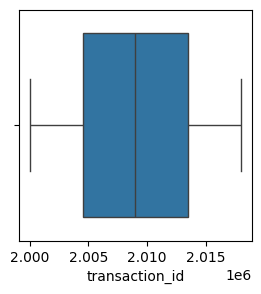

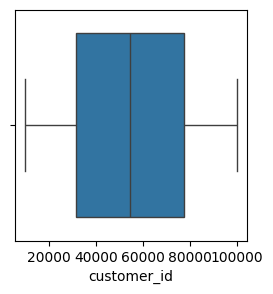

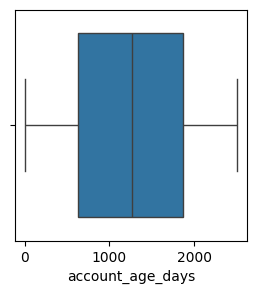

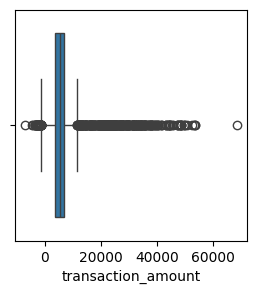

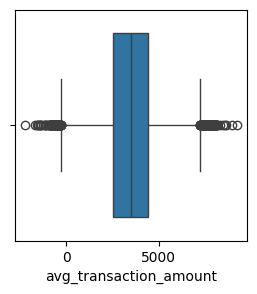

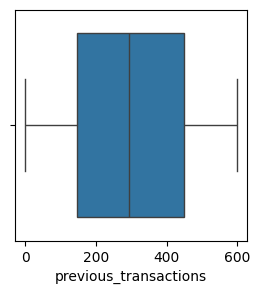

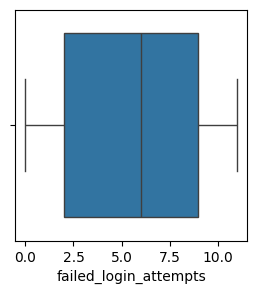

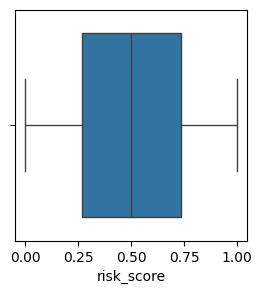

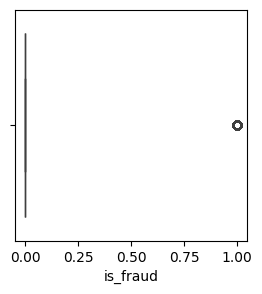

In [ ]:
for i in df_num.columns:
  plt.figure(figsize =(3,3))
  sns.boxplot(x = i ,data = df_num)
  plt.show()

OUTLIER TREATMENT

In [ ]:
def outlier_capping(df, column):

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr

    df[column] = np.where(
        df[column] > upper_limit,
        upper_limit,
        df[column]
    )

    df[column] = np.where(
        df[column] < lower_limit,
        lower_limit,
        df[column]
    )

    return df

In [ ]:
for col in df_num.columns:
    df_num = outlier_capping(df_num, col)


again checking if outliers treated or not

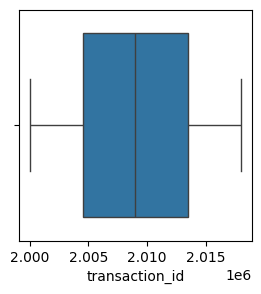

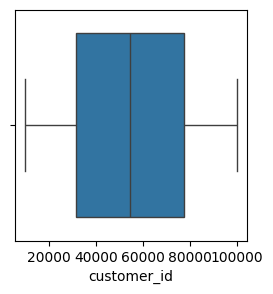

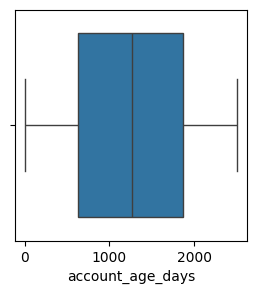

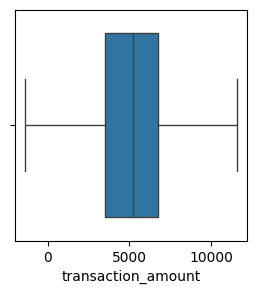

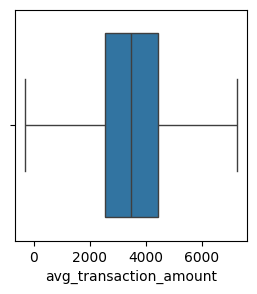

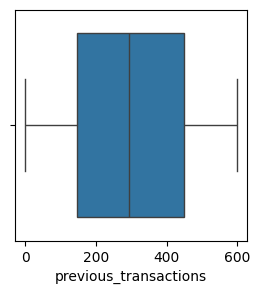

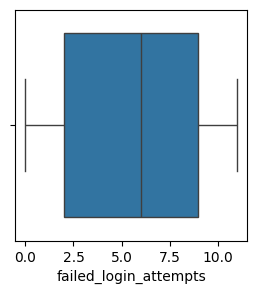

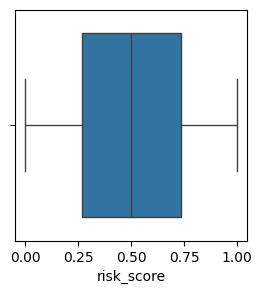

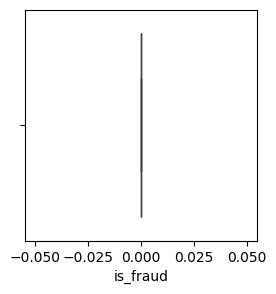

In [ ]:
for i in df_num.columns:
  plt.figure(figsize =(3,3))
  sns.boxplot(x =i, data = df_num)
  plt.show()

In [ ]:
df_num

,transaction_id,customer_id,account_age_days,transaction_amount,avg_transaction_amount,previous_transactions,failed_login_attempts,risk_score,is_fraud
0,2000000.0,25795.0,489.0,7557.35000,2581.53,169.0,9.0,0.601,0.0
1,2000001.0,10860.0,1223.0,3626.45000,4462.66,513.0,8.0,0.648,0.0
2,2000002.0,86820.0,655.0,4561.62000,4418.63,333.0,1.0,0.183,0.0
3,2000003.0,64886.0,1084.0,3852.07000,2410.83,15.0,1.0,0.936,0.0
4,2000004.0,16265.0,2456.0,5009.51000,5031.36,382.0,1.0,0.905,0.0
...,...,...,...,...,...,...,...,...,...
17995,2017995.0,19275.0,2126.0,4524.31000,3039.84,577.0,2.0,0.395,0.0
17996,2017996.0,55606.0,2434.0,4694.37000,3060.48,556.0,3.0,0.316,0.0
17997,2017997.0,11658.0,2221.0,7793.87000,5599.38,214.0,2.0,0.077,0.0
17998,2017998.0,82468.0,564.0,9124.80000,3432.53,328.0,2.0,0.120,0.0


# EXPLORATORY DATA ANALYSIS

HISTPLOT

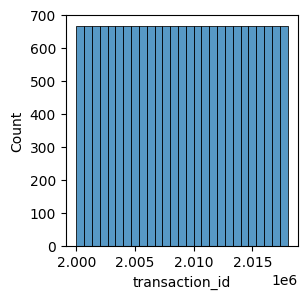

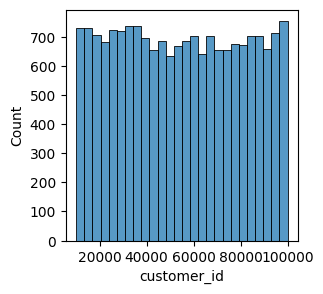

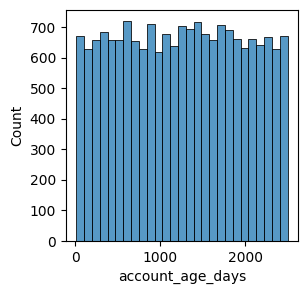

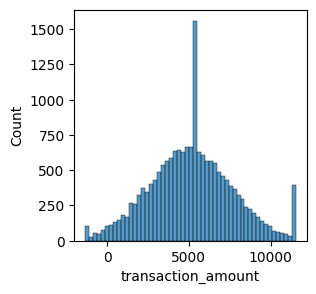

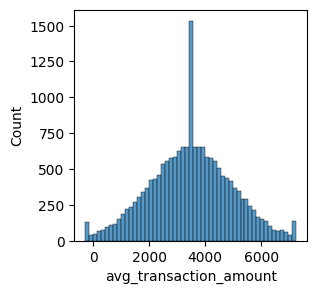

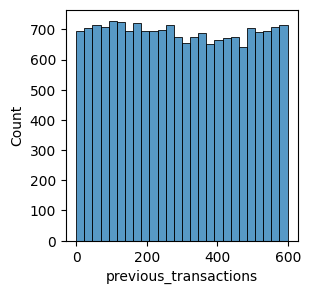

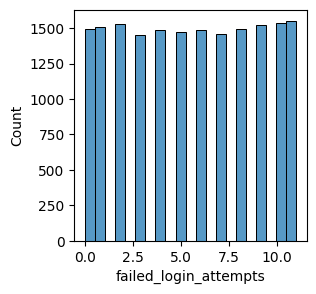

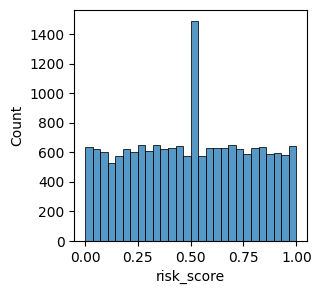

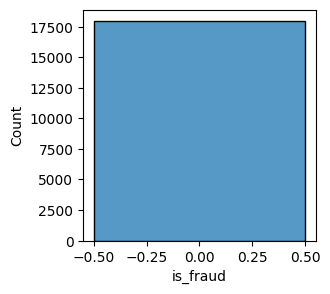

In [ ]:
for i in df_num.columns:
  plt.figure(figsize = (3,3))
  sns.histplot(x = i,data =df_num)
  plt.show()

COUNT PLOT  FOR CATEGORICAL COLN

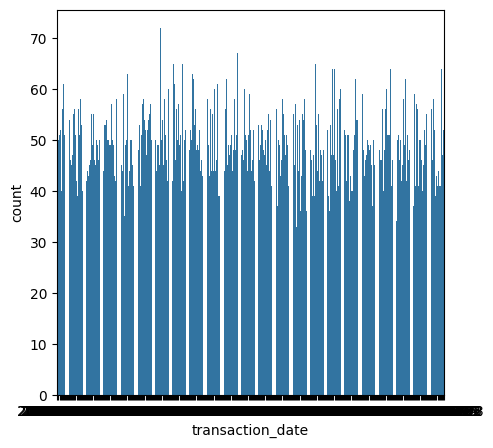

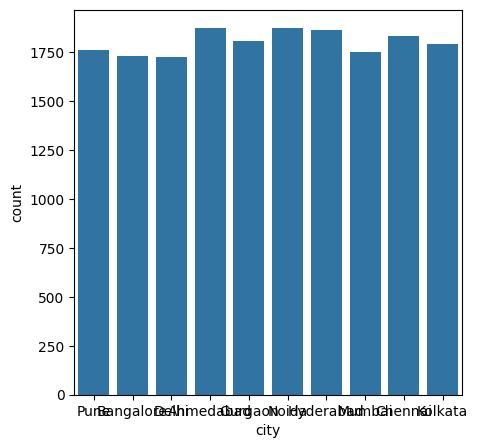

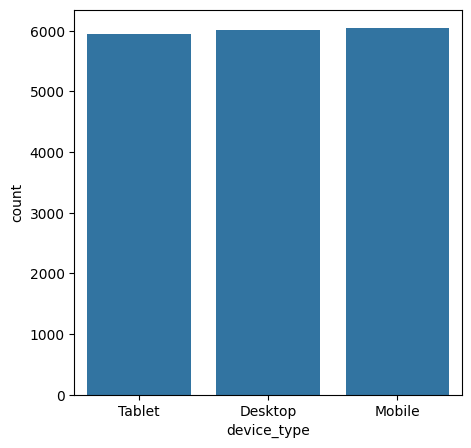

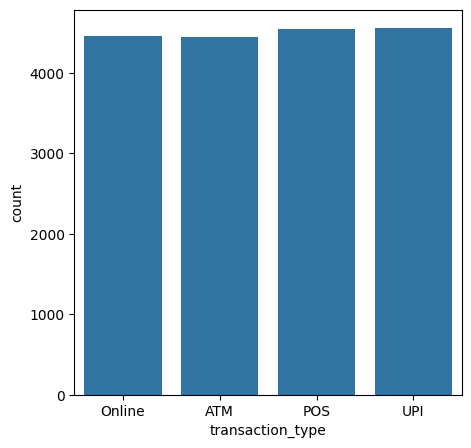

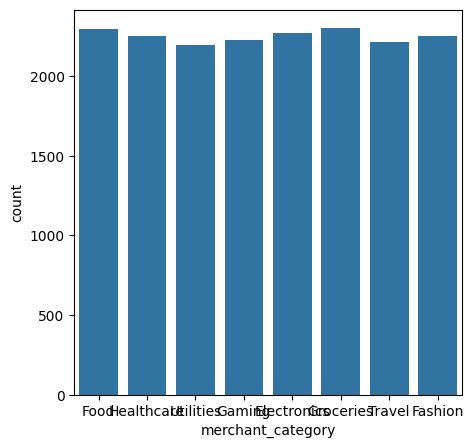

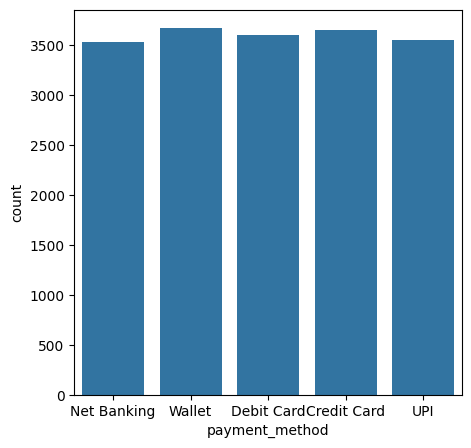

In [ ]:
for i in df_cat.columns:
  plt.figure(figsize =(5,5))
  sns.countplot( x=i , data = df_cat)
  plt.show()

SCATTERPLOT BETWEEN TWO NUMERICAL COLN
FOR CORRELATION

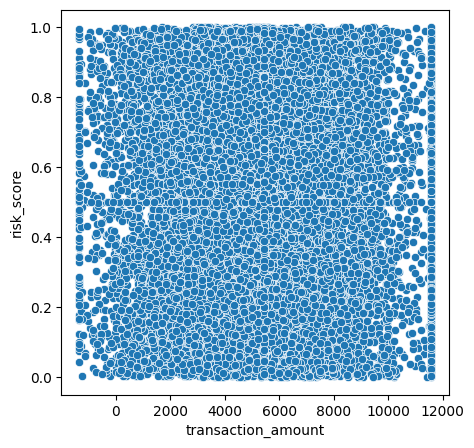

In [ ]:
plt.figure(figsize =(5,5))
sns.scatterplot(x = 'transaction_amount',y = 'risk_score', data = df_num )
plt.show()

scatterplot betweeen transaction amount and fraud_risk

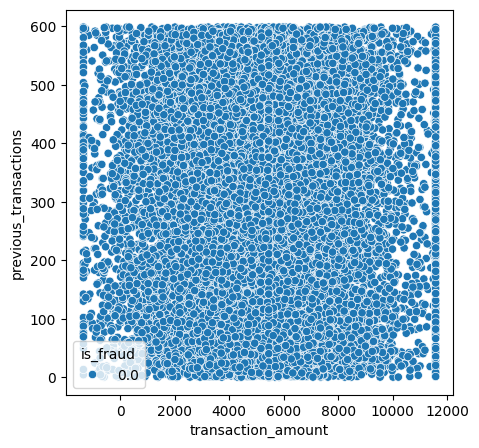

In [ ]:
plt.figure(figsize =(5,5))
sns.scatterplot(x = 'transaction_amount',y = 'previous_transactions',hue= 'is_fraud',data = df_num)
plt.show()

hist plot between transaction id and avg_transaction_amount

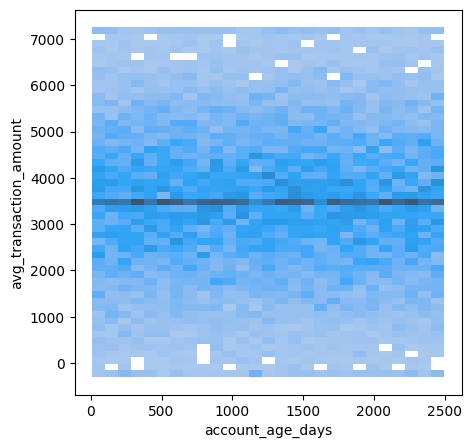

In [ ]:
plt.figure(figsize =(5,5))
sns.histplot(x = 'account_age_days', y = 'avg_transaction_amount',data = df_num)
plt.show()

heatmap using corelation

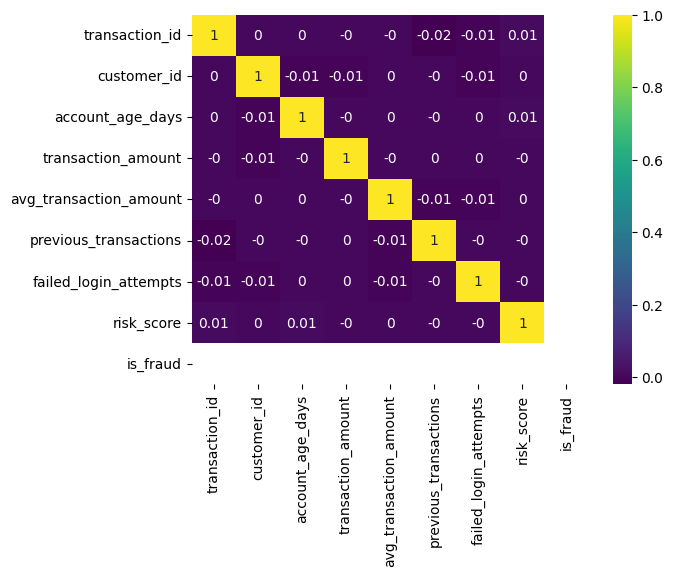

In [ ]:
corr = df_num.corr()
corr1 = corr.round(2)
sns.heatmap(corr1 , annot = True, cmap = 'viridis')
plt.show()

# Encoding --- convert categorical coln into numerical coln

In [ ]:
df_cat =df_cat.drop(columns = ['transaction_date'],axis = 1)
df_cat

,city,device_type,transaction_type,merchant_category,payment_method
0,Pune,Tablet,Online,Food,Net Banking
1,Bangalore,Desktop,ATM,Healthcare,Wallet
2,Delhi,Desktop,POS,Healthcare,Wallet
3,Bangalore,Tablet,UPI,Utilities,Debit Card
4,Pune,Tablet,UPI,Gaming,Credit Card
...,...,...,...,...,...
17995,Chennai,Tablet,UPI,Utilities,Wallet
17996,Gurgaon,Desktop,UPI,Fashion,Debit Card
17997,Pune,Desktop,UPI,Food,Credit Card
17998,Kolkata,Tablet,UPI,Healthcare,Wallet


In [ ]:
from sklearn.preprocessing import OneHotEncoder
oe = OneHotEncoder()
data_cat = pd.get_dummies(df_cat,drop_first = True).astype(int)

In [ ]:
data_cat

,city_Bangalore,city_Chennai,city_Delhi,city_Gurgaon,city_Hyderabad,city_Kolkata,city_Mumbai,city_Noida,city_Pune,device_type_Mobile,...,merchant_category_Food,merchant_category_Gaming,merchant_category_Groceries,merchant_category_Healthcare,merchant_category_Travel,merchant_category_Utilities,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
17996,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
17997,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
17998,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


# data concatenation

In [ ]:
df1 = pd.concat([df_num,data_cat],axis = 1)
df1 = df1.drop(columns =['transaction_id','customer_id'],axis = 1)
df1

,account_age_days,transaction_amount,avg_transaction_amount,previous_transactions,failed_login_attempts,risk_score,is_fraud,city_Bangalore,city_Chennai,city_Delhi,...,merchant_category_Food,merchant_category_Gaming,merchant_category_Groceries,merchant_category_Healthcare,merchant_category_Travel,merchant_category_Utilities,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,489.0,7557.35000,2581.53,169.0,9.0,0.601,0.0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
1,1223.0,3626.45000,4462.66,513.0,8.0,0.648,0.0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
2,655.0,4561.62000,4418.63,333.0,1.0,0.183,0.0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
3,1084.0,3852.07000,2410.83,15.0,1.0,0.936,0.0,1,0,0,...,0,0,0,0,0,1,1,0,0,0
4,2456.0,5009.51000,5031.36,382.0,1.0,0.905,0.0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,2126.0,4524.31000,3039.84,577.0,2.0,0.395,0.0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
17996,2434.0,4694.37000,3060.48,556.0,3.0,0.316,0.0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
17997,2221.0,7793.87000,5599.38,214.0,2.0,0.077,0.0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
17998,564.0,9124.80000,3432.53,328.0,2.0,0.120,0.0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


# machine learning algorithms

1 . LinearRegression

segregate and x and y

In [ ]:
X = df1.drop(columns=['transaction_amount'],axis = 1)
Y = df1['transaction_amount']

splitting into train and test

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size =.2, random_state = 42)

scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

building the model

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

train model on train data

In [ ]:
model.fit(X_train,Y_train)

LinearRegression()

prediction on test data

In [ ]:
Y_pred_test = model.predict(X_test)

In [ ]:
df_test = pd.DataFrame({'Y_test':Y_test,'Y_pred_test':Y_pred_test})
df_test

,Y_test,Y_pred_test
2574,4446.89,5478.570976
7496,5020.33,5092.450849
9210,9627.35,5212.453042
5456,3364.84,5287.450968
736,5711.60,4928.961162
...,...,...
9945,1924.44,5331.157320
9236,1151.90,5305.356882
14176,4812.84,5005.605295
13889,1727.39,5196.436661


prediction on train data

In [ ]:
Y_pred_train = model.predict(X_train)

In [ ]:
df_train = pd.DataFrame({'Y_train':Y_train,'Y_pred_train':Y_pred_train})
df_train

,Y_train,Y_pred_train
1921,6512.73000,5346.052644
5732,6862.86000,5301.806983
2455,6984.39000,5251.597964
12131,2631.58000,5109.647653
16612,11579.93625,5017.787312
...,...,...
11284,3395.82000,5177.728681
11964,3035.01000,5251.253821
5390,7807.43000,5237.185404
860,8876.34000,5048.211205


EVALAUATION METRICS ----

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error,root_mean_squared_error

In [ ]:
# r2_score for train and test data
r2_train = r2_score(Y_train,Y_pred_train)
print(r2_train)

r2_test = r2_score(Y_test,Y_pred_test)
print(r2_test)

0.0029016376262157584
-0.0029567045159384353


In [ ]:
# mean squared error for train and test data
mse_train = mean_squared_error(Y_train,Y_pred_train)
print(mse_train)

mse_test = mean_squared_error(Y_test,Y_pred_test)
print(mse_test)

6442291.930340007
6563638.093775612


In [ ]:
# root mean squared error
rmse_train = np.mean(mse_train)
print(rmse_train)

rmse_test = np.mean(mse_test)
print(rmse_test)

6442291.930340007
6563638.093775612


# LogisticRegression

segregate into X and y

In [ ]:
X = df1.drop(columns =['is_fraud'],axis = 1)
Y = df['is_fraud']

splitting into train and test

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = .2, random_state = 42)

scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

building the model

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

train model on train data

In [ ]:
model.fit(X_train,Y_train)

LogisticRegression()

prediction on test data

In [ ]:
Y_pred_test = model.predict(X_test)

In [ ]:
df_test_lr = pd.DataFrame({'Y_test':Y_test,'Y_pred_test':Y_pred_test})
df_test_lr

,Y_test,Y_pred_test
2574,1,0
7496,0,0
9210,1,0
5456,0,0
736,0,0
...,...,...
9945,0,0
9236,0,0
14176,1,0
13889,0,0


prediction on train data

In [ ]:
Y_pred_train = model.predict(X_train)

In [ ]:
df_train_lr = pd.DataFrame({'Y_train':Y_train,'Y_pred_train':Y_pred_train})
df_train_lr

,Y_train,Y_pred_train
1921,1,0
5732,1,0
2455,0,0
12131,0,0
16612,0,0
...,...,...
11284,0,0
11964,0,0
5390,0,0
860,0,0


evaluation metrics

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report,roc_auc_score,roc_curve

In [ ]:
# confusion_matrix for train and test data
cm_train = confusion_matrix(Y_train,Y_pred_train)
print(cm_train)

cm_test = confusion_matrix(Y_test,Y_pred_test)
print(cm_test)

[[13292     1]
 [ 1068    39]]
[[3332    1]
 [ 256   11]]


In [ ]:
# accuracy score for train and test data
acc_train = accuracy_score(Y_train,Y_pred_train)
print(acc_train)

acc_test = accuracy_score(Y_test,Y_pred_test)
print(acc_test)

0.9257638888888889
0.9286111111111112


In [ ]:
# classification report
cr_train = classification_report(Y_train,Y_pred_train)
print(cr_train)

cr_test = classification_report(Y_test,Y_pred_test)
print(cr_test)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     13293
           1       0.97      0.04      0.07      1107

    accuracy                           0.93     14400
   macro avg       0.95      0.52      0.51     14400
weighted avg       0.93      0.93      0.89     14400

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      3333
           1       0.92      0.04      0.08       267

    accuracy                           0.93      3600
   macro avg       0.92      0.52      0.52      3600
weighted avg       0.93      0.93      0.90      3600



In [ ]:
# roc_suc score for train and test data
roc_train = roc_auc_score(Y_train,Y_pred_train)
print(roc_train)

roc_test = roc_auc_score(Y_test,Y_pred_test)
print(roc_test)

0.517577562370072
0.5204492359348295


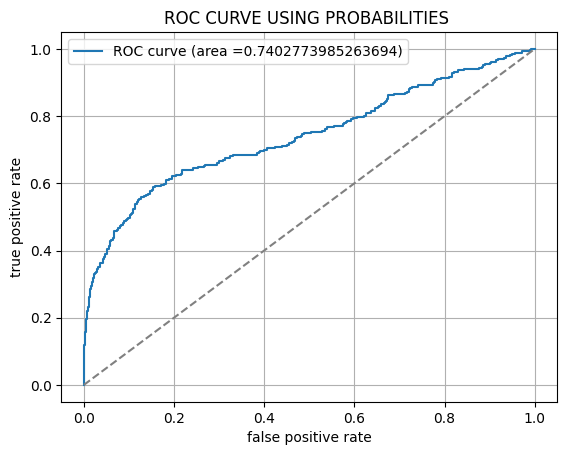

In [ ]:
# roc curve using probabilities
Y_pred_test_proba = model.predict_proba(X_test)[:,1]
fpr_proba,tpr_proba,thresholds_proba = roc_curve(Y_test,Y_pred_test_proba)
plt.plot(fpr_proba,tpr_proba , label = f'ROC curve (area ={roc_auc_score(Y_test,Y_pred_test_proba)})')
plt.plot([0,1],[0,1],linestyle ='--',color = 'grey')
plt.title('ROC CURVE USING PROBABILITIES ')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.legend()
plt.grid()
plt.show()

# KNeighborsClassifier

segregate into X and y

In [ ]:
X = df1.drop(columns =['is_fraud'],axis = 1)
Y = df['is_fraud']

splitting into train and test

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = .2 ,random_state = 42)

building the model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier()

train model on train data

In [ ]:
neigh.fit(X_train,Y_train)

KNeighborsClassifier()

In [ ]:
acc =[]
for i in range(1,100,2):
  neigh = KNeighborsClassifier(n_neighbors =i)
  neigh.fit(X_train,Y_train)
  Y_pred_test = np.mean(neigh.predict(X_test)==Y_test)
  Y_pred_train = np.mean(neigh.predict(X_train)==Y_train)
  acc.append([i,Y_pred_train,Y_pred_test])

In [ ]:
acc = pd.DataFrame(acc,columns =['k','Y_pred_train','Y_pred_test'])
acc['differ'] = acc['Y_pred_test']-acc['Y_pred_train']
acc

,k,Y_pred_train,Y_pred_test,differ
0,1,1.000000,0.871667,-0.128333
1,3,0.930486,0.913056,-0.017431
2,5,0.924375,0.923056,-0.001319
3,7,0.924444,0.922778,-0.001667
4,9,0.923611,0.923611,0.000000
5,11,0.923542,0.924444,0.000903
6,13,0.923681,0.924722,0.001042
7,15,0.923264,0.924722,0.001458
8,17,0.923125,0.925000,0.001875
9,19,0.923056,0.924722,0.001667


In [ ]:
# AGAIN BUILDING MODEL
neigh = KNeighborsClassifier(n_neighbors =91)
neigh.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=91)

evaluation metrics

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [ ]:
# confusion_matrix for train and test data
train_cm = confusion_matrix(Y_train,neigh.predict(X_train))
print(train_cm)

test_cm = confusion_matrix(Y_test,neigh.predict(X_test))
print(test_cm)

[[13293     0]
 [ 1107     0]]
[[3333    0]
 [ 267    0]]


In [ ]:
# accuracy score for train and test data
train_acc = accuracy_score(Y_train,neigh.predict(X_train))
print(train_acc)

test_acc = accuracy_score(Y_test,neigh.predict(X_test))
print(test_acc)

0.923125
0.9258333333333333


In [ ]:
# classification report
train_cr = classification_report(Y_train,neigh.predict(X_train))
print(train_cr)

test_cr = classification_report(Y_test,neigh.predict(X_test))
print(test_cr)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.92      1.00      0.96     13293
           1       0.00      0.00      0.00      1107

    accuracy                           0.92     14400
   macro avg       0.46      0.50      0.48     14400
weighted avg       0.85      0.92      0.89     14400

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      3333
           1       0.00      0.00      0.00       267

    accuracy                           0.93      3600
   macro avg       0.46      0.50      0.48      3600
weighted avg       0.86      0.93      0.89      3600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# DecisionTreeClassifier

segregate into X and y

In [ ]:
X = df1.drop(columns =['is_fraud'],axis = 1)
Y = df['is_fraud']

splitting into train and test

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = .2,random_state = 42)

building the model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

train model on train data

In [ ]:
dt.fit(X_train,Y_train)

DecisionTreeClassifier()

plotting the tree

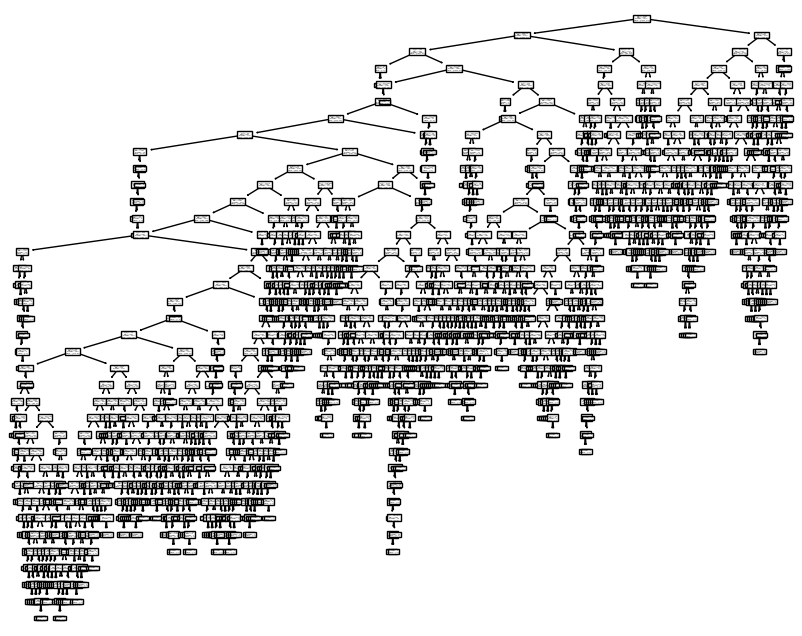

In [ ]:
from sklearn import tree
plt.figure(figsize =(10,8))
tree.plot_tree(dt)
plt.show()

prediction on test data

In [ ]:
Y_pred_test_dt = dt.predict(X_test)

prediction on train data

In [ ]:
Y_pred_train_dt = dt.predict(X_train)

evaluation metrics

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report


In [ ]:
# confusion_matrix for train and test data
train_cm = confusion_matrix(Y_train,Y_pred_train_dt)
print(train_cm)

test_cm = confusion_matrix(Y_test,Y_pred_test_dt)
print(test_cm)

[[13293     0]
 [    0  1107]]
[[3140  193]
 [ 139  128]]


In [ ]:
# accuracy score for train and test data
train_acc = accuracy_score(Y_train,Y_pred_train_dt)
print(train_acc)

test_acc = accuracy_score(Y_test,Y_pred_test_dt)
print(test_acc)


1.0
0.9077777777777778


In [ ]:
# classification report
train_cr = classification_report(Y_train,Y_pred_train_dt)
print(train_cr)

test_cr = classification_report(Y_test,Y_pred_test_dt)
print(test_cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13293
           1       1.00      1.00      1.00      1107

    accuracy                           1.00     14400
   macro avg       1.00      1.00      1.00     14400
weighted avg       1.00      1.00      1.00     14400

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3333
           1       0.40      0.48      0.44       267

    accuracy                           0.91      3600
   macro avg       0.68      0.71      0.69      3600
weighted avg       0.92      0.91      0.91      3600



# RandomForestClassifier

segregate into x and y

In [ ]:
X = df1.drop(columns =['is_fraud'],axis = 1)
Y = df['is_fraud']

SPLITTING INTO TRAIN AND TEST

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size =.2,random_state = 42)

building the model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

train model on train data

In [ ]:
rf.fit(X_train,Y_train)

RandomForestClassifier()

prediction on test data

In [ ]:
Y_pred_test_rf = rf.predict(X_test)

prediction on train data

In [ ]:
Y_pred_train_rf = rf.predict(X_train)

evaluation metrics

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [ ]:
# confusion matrix for train and test data
train_cm = confusion_matrix(Y_train,Y_pred_train_rf)
print(train_cm)

test_cm = confusion_matrix(Y_test,Y_pred_test_rf)
print(test_cm)

[[13293     0]
 [    2  1105]]
[[3333    0]
 [ 157  110]]


In [ ]:
# accuracy score for train and test data
train_acc = accuracy_score(Y_train,Y_pred_train_rf)
print(train_acc)

test_acc = accuracy_score(Y_test,Y_pred_test_rf)
print(test_acc)

0.9998611111111111
0.9563888888888888


In [ ]:
# classification report for train and test data
train_cr = classification_report(Y_train,Y_pred_train_rf)
print(train_cr)

test_cr = classification_report(Y_test,Y_pred_test_rf)
print(test_cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13293
           1       1.00      1.00      1.00      1107

    accuracy                           1.00     14400
   macro avg       1.00      1.00      1.00     14400
weighted avg       1.00      1.00      1.00     14400

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3333
           1       1.00      0.41      0.58       267

    accuracy                           0.96      3600
   macro avg       0.98      0.71      0.78      3600
weighted avg       0.96      0.96      0.95      3600



# using gradient boosting

importing libraries

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

segregate into x and y

In [ ]:
X = df1.drop(columns =['is_fraud'],axis =1)
Y = df['is_fraud']

splitting into train and test

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = .2,random_state = 42)

building the model

In [ ]:
model = GradientBoostingClassifier()

train model on train data

In [ ]:
model.fit(X_train,Y_train)

GradientBoostingClassifier()

prediction on test and train data

In [ ]:
Y_pred_test_gb = model.predict(X_test)

prediction on train data

In [ ]:
Y_pred_train_gb = model.predict(X_train)

evaluation metrics

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report


In [ ]:
# confusion_matrix for train and test data
train_cm = confusion_matrix(Y_train,Y_pred_train_gb)
print(train_cm)

test_cm = confusion_matrix(Y_test,Y_pred_test_gb)
print(test_cm)

[[13291     2]
 [  603   504]]
[[3330    3]
 [ 154  113]]


In [ ]:
# accuracy score for train and test data
train_acc = accuracy_score(Y_train,Y_pred_train_gb)
print(train_acc)

test_acc = accuracy_score(Y_test,Y_pred_test_gb)
print(test_acc)

0.9579861111111111
0.9563888888888888


In [ ]:
# classification report
train_cr = classification_report(Y_train,Y_pred_train_gb)
print(train_cr)

test_cr = classification_report(Y_test,Y_pred_test_gb)
print(test_cr)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     13293
           1       1.00      0.46      0.62      1107

    accuracy                           0.96     14400
   macro avg       0.98      0.73      0.80     14400
weighted avg       0.96      0.96      0.95     14400

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3333
           1       0.97      0.42      0.59       267

    accuracy                           0.96      3600
   macro avg       0.96      0.71      0.78      3600
weighted avg       0.96      0.96      0.95      3600



# XGBOOST ---

SEGREGATE INTO X AND Y

In [ ]:
X = df1.drop(columns =['is_fraud'],axis = 1)
Y = df['is_fraud']

splitting into train and test

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size =.2,random_state =42)

building the model

In [ ]:
import xgboost as xgb
xgb_clf = xgb.XGBClassifier()

train model on train data

In [ ]:
xgb_clf.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

prediction on train and test data

In [ ]:
Y_pred_test_xg = xgb_clf.predict(X_test)

prediction on train data

In [ ]:
Y_pred_train_xg = xgb_clf.predict(X_train)

evaluation metrics

In [ ]:
# confusion matrix for train and test data
train_cm = confusion_matrix(Y_train,Y_pred_train_xg)
print(train_cm)

test_cm = confusion_matrix(Y_test,Y_pred_test_xg)
print(test_cm)

[[13293     0]
 [  233   874]]
[[3326    7]
 [ 152  115]]


In [ ]:
# accuracy score for train and test data
train_acc = accuracy_score(Y_train,Y_pred_train_xg)
print(train_acc)

test_acc = accuracy_score(Y_test,Y_pred_test_xg)
print(test_acc)

0.9838194444444445
0.9558333333333333


In [ ]:
# classification report
train_cr = classification_report(Y_train,Y_pred_train_xg)
print(train_cr)

test_cr = classification_report(Y_test,Y_pred_test_xg)
print(test_cr)
#

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     13293
           1       1.00      0.79      0.88      1107

    accuracy                           0.98     14400
   macro avg       0.99      0.89      0.94     14400
weighted avg       0.98      0.98      0.98     14400

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3333
           1       0.94      0.43      0.59       267

    accuracy                           0.96      3600
   macro avg       0.95      0.71      0.78      3600
weighted avg       0.96      0.96      0.95      3600



In [ ]:
# comparision of accuracy score for all classifier model



In [ ]:
from sklearn.metrics import accuracy_score

# Accuracy scores from previous models
logistic_regression_accuracy = acc_test # from Logistic Regression
knn_accuracy = acc['Y_pred_test'].max() # Best test accuracy from KNN tuning
decision_tree_accuracy = test_acc # from Decision Tree Classifier
random_forest_accuracy = accuracy_score(Y_test, Y_pred_test_rf) # from RandomForestClassifier
gradient_boosting_accuracy = accuracy_score(Y_test, Y_pred_test_gb) # from GradientBoostingClassifier
xgboost_accuracy = accuracy_score(Y_test, Y_pred_test_xg) # from XGBoost

# Create a DataFrame to display the comparison
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'K-Nearest Neighbors',
        'Decision Tree Classifier',
        'Random Forest Classifier',
        'Gradient Boosting Classifier',
        'XGBoost'
    ],
    'Test Accuracy': [
        logistic_regression_accuracy,
        knn_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        gradient_boosting_accuracy,
        xgboost_accuracy
    ]
})

# Display the comparison table
display(comparison_df.sort_values(by='Test Accuracy', ascending=False))


,Model,Test Accuracy
4,Gradient Boosting Classifier,0.956389
3,Random Forest Classifier,0.956389
2,Decision Tree Classifier,0.955833
5,XGBoost,0.955833
0,Logistic Regression,0.928611
1,K-Nearest Neighbors,0.925833


exporting dataset to implement in powerBI

In [ ]:
df["predicted_fraud"] = model.predict(X)

In [ ]:
df.to_csv("fraud_dashboard_data.csv", index=False)